# Analysis of ESA CCI 300m Land Cover Data for Italy (1992-2022)

## Evaluation of Methodology and Outputs

The analytical approach using the **300m ESA CCI Land Cover** dataset demonstrates a technically sound and logically correct methodology. The script's core strength—dynamically calculating pixel area—is validated perfectly, with consistent pixel areas of **90,000 m²** (300m × 300m) throughout the analysis.

### Key Observations:

1.  **Total Area Consistency:**
    - The calculated total area for Italy remains constant at **301,393.17 km²** across all years
    - This perfect consistency indicates high-quality, pre-processed data with no missing pixels or grid shifts
    - Provides a stable foundation for robust change detection analysis

2.  **Dominant Land Cover Classes:**
    - **Cropland**: Dominant class (~53-54% of total area)
    - **Forest**: Second largest class (~29-30% of total area) 
    - **Grassland**: Significant class (~6.5% of total area)
    - These three classes consistently account for approximately **90%** of Italy's land cover

3.  **Pronounced Land Cover Trends:**
    - **Urbanization (Built-up)**: Most striking trend - built-up areas more than **doubled** from **6,705 km² (2.22%) in 1992** to **13,739 km² (4.56%) in 2022**
    - **Deforestation**: Clear decline in forest cover from **91,713 km² (30.43%) in 1992** to **88,733 km² (29.44%) in 2022**
    - **Cropland Reduction**: Decreasing trend from **163,373 km² (54.21%) in 1992** to **160,501 km² (53.25%) in 2022**
    - **Bareland Retreat**: Area nearly halved from **9,007 km² (2.99%) to 6,202 km² (2.06%)**

## Key Findings for Thesis

The analysis reveals a compelling narrative of significant anthropogenic land cover change in Italy over three decades:

- **Urban expansion** occurred primarily at the expense of agricultural and natural landscapes
- **Forest loss** represents a critical environmental change trend with implications for biodiversity and carbon sequestration
- **Cropland reduction** suggests land conversion to urban uses
- **Bareland decrease** may indicate land reclamation efforts, natural revegetation, or improved classification accuracy

The 300m ESA CCI data provides a robust, continental-scale perspective confirming widespread human-induced land cover transformations throughout Italy, offering valuable insights for environmental monitoring and policy planning.

*Note: The bar chart values (e.g., 91713 and 88733 for Forest) represent area in km², showing rounded values from the original data (91,712.88 and 88,732.98 km² respectively). This visualization effectively demonstrates the net change over the study period.*



In [2]:
import os

# Define the directory path
directory_path = '/Users/ghulamabbaszafari/Downloads/rest/esa_Italy'

# List all files in the directory
files = os.listdir(directory_path)

# Filter out unwanted files like .DS_Store
filtered_files = [file for file in files if file != '.DS_Store']

# Print the filtered list of files
for file in filtered_files:
    print(file)




esa_cci_2001_clipped.tif.aux.xml
esa_cci_1999_clipped.tif.aux.xml
esa_cci_2018_clipped.tif.aux.xml
esa_cci_2011_clipped.tif
esa_cci_2000_clipped.tif.aux.xml
esa_cci_1998_clipped.tif.aux.xml
esa_cci_1995_clipped.tif
esa_cci_2018_clipped.tif
essa_cci_2019_clipped.tif.aux.xml
esa_cci_2003_clipped.tif.aux.xml
esa_cci_2004_clipped.tif
esa_cci_2002_clipped.tif.aux.xml
esa_cci_2004_clipped.tif.aux.xml
esa_cci_2001_clipped.tif
esa_cci_2005_clipped.tif.aux.xml
esa_cci_2014_clipped.tif
esa_cci_2006_clipped.tif.aux.xml
esa_cci_1999_clipped.tif
esa_cci_2007_clipped.tif.aux.xml
esa_cci_2008_clipped.tif
esa_cci_2013_clipped.tif.aux.xml
esa_cci_1992_clipped.tif.aux.xml
esa_cci_2012_clipped.tif.aux.xml
esa_cci_1993_clipped.tif.aux.xml
esa_cci_2017_clipped.tif
esa_cci_2002_clipped.tif
esa_cci_2008_clipped.tif.aux.xml
esa_cci_2011_clipped.tif.aux.xml
esa_cci_1993_clipped.tif
esa_cci_2009_clipped.tif.aux.xml
esa_cci_2010_clipped.tif.aux.xml
esa_cci_1997_clipped.tif.aux.xml
esa_cci_2007_clipped.tif
esa_cc

In [3]:
import os
import grass.script as gs

# Class labels for reclassification
class_labels = {
    5: 'Shrubland',
    7: 'Grassland',
    8: 'Cropland',
    9: 'Wetland',
    11: 'Lichens and mosses',
    12: 'Bareland',
    13: 'Built-up',
    15: 'Water',
    16: 'Permanent ice and Snow',
    20: 'Forest',
    255: 'No data'
}

# Color rules for visualization
color_map = {
    'Shrubland': '#8b4513',
    'Grassland': '#32cd32',
    'Cropland': '#ffd700',
    'Wetland': '#4682b4',
    'Lichens and mosses': '#a9cda9',
    'Bareland': '#c2b280',
    'Built-up': '#808080',
    'Water': '#1e90ff',
    'Permanent ice and Snow': '#b0c4de',
    'Forest': '#006400',
    'No data': '#ffffff'
}

def import_esa_landcover_data():
    """Import GLC_FCS30D land cover TIFF rasters into GRASS with styling."""
    
    directory_path = '/Users/ghulamabbaszafari/Downloads/rest/esa_Italy'

    # Get only .tif files (excluding .aux.xml files)
    tif_files = [
        f for f in os.listdir(directory_path)
        if f.endswith('.tif') and not f.startswith('.') and not f.endswith('.aux.xml')
    ]
    tif_files.sort()

    print(f"Found {len(tif_files)} TIFF raster files to import.")

    raster_dict = {}
    failed_imports = []

    for tif_file in tif_files:
        try:
            base_name = os.path.splitext(tif_file)[0]  # Remove .tif extension
            
            # Extract year from filename (format: esa_cci_YYYY_clipped)
            try:
                year = base_name.split('_')[2]
                if not year.isdigit() or len(year) != 4:
                    raise ValueError(f"Invalid year format in filename: {tif_file}")
            except (IndexError, ValueError) as e:
                print(f"⚠️ Skipping {tif_file} (could not extract year: {str(e)})")
                continue

            # Create unique raster name in cci_YYYY format
            raster_name = f"cci_{year}"
            input_path = os.path.join(directory_path, tif_file)

            print(f"\n📦 Importing: {tif_file} → {raster_name}")

            # Import TIFF file
            gs.run_command('r.in.gdal',
                         input=input_path,
                         output=raster_name,
                         flags='o',
                         overwrite=True)

            # Set 0 and 255 to NULL
            gs.run_command('r.null', map=raster_name, setnull='0,255')

            # Apply category labels
            label_rules = "\n".join(f"{k}\t{v}" for k, v in class_labels.items())
            gs.write_command('r.category', map=raster_name, rules='-', stdin=label_rules)

            # Apply color rules
            color_rules = "\n".join(
                f"{k} {color_map[v]}" for k, v in class_labels.items() if v in color_map
            )
            gs.write_command('r.colors', map=raster_name, rules='-', stdin=color_rules)

            raster_dict[year] = raster_name
            print(f"✅ Imported: {raster_name}")

        except Exception as e:
            print(f"❌ FAILED: {tif_file} → {str(e)}")
            failed_imports.append(tif_file)

    # Summary
    if failed_imports:
        print("\n❌ Failed imports:")
        for f in failed_imports:
            print(f" - {f}")
    else:
        print("\n✅ All TIFF files imported successfully!")

    return raster_dict


if __name__ == "__main__":
    import_esa_landcover_data()

    

Found 31 TIFF raster files to import.

📦 Importing: esa_cci_1992_clipped.tif → cci_1992


Over-riding projection check
Importing raster map <cci_1992>...


Color table for raster map <cci_1992> set to 'rules'
Over-riding projection check
Importing raster map <cci_1993>...


✅ Imported: cci_1992

📦 Importing: esa_cci_1993_clipped.tif → cci_1993




Color table for raster map <cci_1993> set to 'rules'
Over-riding projection check
Importing raster map <cci_1994>...


✅ Imported: cci_1993

📦 Importing: esa_cci_1994_clipped.tif → cci_1994


...

Over-riding projection check
Importing raster map <cci_2021>...


Color table for raster map <cci_2021> set to 'rules'


✅ Imported: cci_2021

📦 Importing: esa_cci_2022_clipped.tif → cci_2022


Over-riding projection check
Importing raster map <cci_2022>...




✅ Imported: cci_2022

✅ All TIFF files imported successfully!


Color table for raster map <cci_2022> set to 'rules'


In [1]:
import grass.script as gs
import pandas as pd
from tabulate import tabulate
from datetime import datetime
import os

# Get current timestamp for unique filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Class labels
class_labels = {
    5: 'Shrubland',
    7: 'Grassland',
    8: 'Cropland',
    9: 'Wetland',
    11: 'Lichens and mosses',
    12: 'Bareland',
    13: 'Built-up',
    15: 'Water',
    16: 'Permanent ice and Snow',
    20: 'Forest',
    255: 'No data'
}

# Output directory
output_dir = "cci_italy_stats_output2"
os.makedirs(output_dir, exist_ok=True)

# Unique output filenames
output_files = {
    'detailed': os.path.join(output_dir, f"cci_italy_detailed_stats_{timestamp}.csv"),
    'totals': os.path.join(output_dir, f"cci_italy_yearly_totals_{timestamp}.csv"),
    'summary': os.path.join(output_dir, f"cci_italy_summary_table_{timestamp}.csv")
}

# Explicit list of all 31 rasters to process (1992-2022)
TARGET_RASTERS = [
    "cci_1992@PERMANENT",
    "cci_1993@PERMANENT",
    "cci_1994@PERMANENT",
    "cci_1995@PERMANENT",
    "cci_1996@PERMANENT",
    "cci_1997@PERMANENT",
    "cci_1998@PERMANENT",
    "cci_1999@PERMANENT",
    "cci_2000@PERMANENT",
    "cci_2001@PERMANENT",
    "cci_2002@PERMANENT",
    "cci_2003@PERMANENT",
    "cci_2004@PERMANENT",
    "cci_2005@PERMANENT",
    "cci_2006@PERMANENT",
    "cci_2007@PERMANENT",
    "cci_2008@PERMANENT",
    "cci_2009@PERMANENT",
    "cci_2010@PERMANENT",
    "cci_2011@PERMANENT",
    "cci_2012@PERMANENT",
    "cci_2013@PERMANENT",
    "cci_2014@PERMANENT",
    "cci_2015@PERMANENT",
    "cci_2016@PERMANENT",
    "cci_2017@PERMANENT",
    "cci_2018@PERMANENT",
    "cci_2019@PERMANENT",
    "cci_2020@PERMANENT",
    "cci_2021@PERMANENT",
    "cci_2022@PERMANENT"
]

def format_number(num):
    """Format number with thousands separator and 2 decimal places"""
    return f"{num:,.2f}"

def format_percentage(num, total):
    """Calculate and format percentage"""
    return f"{(num/total)*100:.2f}%" if total > 0 else "0.00%"

def get_pixel_area(raster_name):
    """Get accurate pixel area in square meters"""
    region = gs.parse_command('g.region', flags='pg', raster=raster_name.split('@')[0])
    nsres = float(region['nsres'])
    ewres = float(region['ewres'])
    return nsres * ewres  # Area in square meters

def generate_yearly_stats(raster_name):
    """Generate statistics for a single year with proper area calculation"""
    try:
        # First get the pixel area for this raster
        pixel_area_m2 = get_pixel_area(raster_name)
        
        # Get statistics with -a flag to get area in map units (m²)
        stats = gs.read_command('r.stats', flags='an', input=raster_name, separator='space').strip().splitlines()
        
        if not stats:
            print(f"Warning: No statistics found for {raster_name}")
            return None, 0

        results = []
        total_area_m2 = 0
        year = raster_name.replace("glc_", "").replace("@PERMANENT", "")

        for line in stats:
            parts = line.split()
            if len(parts) < 2:  # Now expecting category and area_m2
                continue
            
            cat = parts[0]
            area_m2 = float(parts[1])
            count = area_m2 / pixel_area_m2  # Calculate pixel count
            
            try:
                cat_int = int(cat)
                label = class_labels.get(cat_int, f'Class {cat}')
                area_km2 = area_m2 / 1_000_000
                
                results.append({
                    'class': cat_int,
                    'label': label,
                    'count': count,
                    'area_m2': area_m2,
                    'area_km2': area_km2
                })
                total_area_m2 += area_m2
            except ValueError:
                continue

        # Convert total to km²
        total_area_km2 = total_area_m2 / 1_000_000

        # Sort by area (descending)
        results.sort(key=lambda x: x['area_km2'], reverse=True)

        # Print sample output
        print(f"\nStatistics for {year}:")
        print(f"Pixel area: {pixel_area_m2:.2f} m²")
        print(tabulate(
            [(r['class'], r['label'], f"{r['count']:,.0f}", 
              format_number(r['area_km2']), 
              format_percentage(r['area_km2'], total_area_km2))
             for r in results],
            headers=['Class', 'Label', 'Count', 'Area (km²)', '% of Total'],
            tablefmt='simple'
        ))
        print(f"Total area: {format_number(total_area_km2)} km²")

        return results, total_area_km2

    except Exception as e:
        print(f"Error processing {raster_name}: {str(e)}")
        return None, 0

def generate_all_stats():
    """Generate statistics for all specified rasters"""
    try:
        print(f"\nProcessing {len(TARGET_RASTERS)} land cover rasters")

        all_data = []
        yearly_totals = []

        for raster_name in TARGET_RASTERS:
            stats, total_area = generate_yearly_stats(raster_name)
            if not stats:
                print(f"Warning: Could not process {raster_name}")
                continue

            year = raster_name.replace("glc_", "").replace("@PERMANENT", "")
            yearly_totals.append({
                'Year': year,
                'Total Area (km2)': total_area,
                'Formatted Area': format_number(total_area)
            })

            for item in stats:
                all_data.append({
                    'Year': year,
                    'Class': item['class'],
                    'Label': item['label'],
                    'Count': item['count'],
                    'Area_km2': item['area_km2'],
                    'Area_m2': item['area_m2'],
                    'Percentage': (item['area_km2']/total_area)*100 if total_area else 0
                })

        # Create DataFrames
        df_all = pd.DataFrame(all_data)
        df_totals = pd.DataFrame(yearly_totals)

        # Save to CSV
        df_all.to_csv(output_files['detailed'], index=False)
        df_totals.to_csv(output_files['totals'], index=False)

        print(f"\nSaved detailed statistics to '{output_files['detailed']}'")
        print(f"Saved yearly totals to '{output_files['totals']}'")

        return df_all, df_totals

    except Exception as e:
        print(f"Error in generate_all_stats: {str(e)}")
        return None, None

if __name__ == "__main__":
    print(f"\nStarting analysis at {timestamp}")
    
    detailed_df, totals_df = generate_all_stats()
    
    if detailed_df is not None and not detailed_df.empty:
        # Create summary table
        summary_df = detailed_df.pivot_table(
            index='Year',
            columns='Label',
            values='Area_km2',
            aggfunc='sum'
        ).fillna(0)

        # Ensure consistent column order
        column_order = [label for label in class_labels.values() if label in summary_df.columns]
        summary_df = summary_df[column_order]

        # Save and display
        summary_df.to_csv(output_files['summary'])
        print(f"\nSummary statistics:")
        print(summary_df.to_string(float_format="%.2f"))
        print(f"\nSaved summary table to '{output_files['summary']}'")
        
        print("\nGenerated these output files:")
        for key, filename in output_files.items():
            print(f"- {filename}")
    else:
        print("\nNo data was processed - check for errors above")

        


Starting analysis at 20250731_185220

Processing 31 land cover rasters



Statistics for cci_1992:
Pixel area: 90000.00 m²
  Class  Label                   Count      Area (km²)    % of Total
-------  ----------------------  ---------  ------------  ------------
      8  Cropland                1,815,253  163,372.77    54.21%
     20  Forest                  1,019,032  91,712.88     30.43%
      7  Grassland               202,859    18,257.31     6.06%
     12  Bareland                100,082    9,007.38      2.99%
      5  Shrubland               86,136     7,752.24      2.57%
     13  Built-up                74,498     6,704.82      2.22%
     15  Water                   43,200     3,888.00      1.29%
      9  Wetland                 3,909      351.81        0.12%
     16  Permanent ice and Snow  3,844      345.96        0.11%
Total area: 301,393.17 km²



Statistics for cci_1993:
Pixel area: 90000.00 m²
  Class  Label                   Count      Area (km²)    % of Total
-------  ----------------------  ---------  ------------  ------------
      8  Cropland                1,814,644  163,317.96    54.19%
     20  Forest                  1,018,966  91,706.94     30.43%
      7  Grassland               202,852    18,256.68     6.06%
     12  Bareland                98,865     8,897.85      2.95%
      5  Shrubland               86,115     7,750.35      2.57%
     13  Built-up                76,449     6,880.41      2.28%
     15  Water                   43,170     3,885.30      1.29%
      9  Wetland                 3,908      351.72        0.12%
     16  Permanent ice and Snow  3,844      345.96        0.11%
Total area: 301,393.17 km²



Statistics for cci_1994:
Pixel area: 90000.00 m²
  Class  Label                   Count      Area (km²)    % of Total
-------  ----------------------  ---------  ------------  ------------
      8  Cropland                1,813,935  163,254.15    54.17%
     20  Forest                  1,018,897  91,700.73     30.43%
      7  Grassland               202,837    18,255.33     6.06%
     12  Bareland                97,470     8,772.30      2.91%
      5  Shrubland               86,092     7,748.28      2.57%
     13  Built-up                78,699     7,082.91      2.35%
     15  Water                   43,131     3,881.79      1.29%
      9  Wetland                 3,908      351.72        0.12%
     16  Permanent ice and Snow  3,844      345.96        0.11%
Total area: 301,393.17 km²



Statistics for cci_1995:
Pixel area: 90000.00 m²
  Class  Label                   Count      Area (km²)    % of Total
-------  ----------------------  ---------  ------------  ------------
      8  Cropland                1,807,196  162,647.64    53.97%
     20  Forest                  1,023,455  92,110.95     30.56%
      7  Grassland               204,220    18,379.80     6.10%
     12  Bareland                96,173     8,655.57      2.87%
      5  Shrubland               86,063     7,745.67      2.57%
     13  Built-up                80,995     7,289.55      2.42%
     15  Water                   42,935     3,864.15      1.28%
      9  Wetland                 3,932      353.88        0.12%
     16  Permanent ice and Snow  3,844      345.96        0.11%
Total area: 301,393.17 km²


...


Statistics for cci_2018:
Pixel area: 90000.00 m²
  Class  Label                   Count      Area (km²)    % of Total
-------  ----------------------  ---------  ------------  ------------
      8  Cropland                1,787,604  160,884.36    53.38%
     20  Forest                  984,038    88,563.42     29.38%
      7  Grassland               215,849    19,426.41     6.45%
     13  Built-up                148,761    13,388.49     4.44%
      5  Shrubland               93,094     8,378.46      2.78%
     12  Bareland                70,231     6,320.79      2.10%
     15  Water                   41,477     3,732.93      1.24%
      9  Wetland                 3,915      352.35        0.12%
     16  Permanent ice and Snow  3,844      345.96        0.11%
Total area: 301,393.17 km²



Statistics for cci_2019:
Pixel area: 90000.00 m²
  Class  Label                   Count      Area (km²)    % of Total
-------  ----------------------  ---------  ------------  ------------
      8  Cropland                1,784,796  160,631.64    53.30%
     20  Forest                  986,908    88,821.72     29.47%
      7  Grassland               216,033    19,442.97     6.45%
     13  Built-up                148,790    13,391.10     4.44%
      5  Shrubland               92,748     8,347.32      2.77%
     12  Bareland                70,300     6,327.00      2.10%
     15  Water                   41,477     3,732.93      1.24%
      9  Wetland                 3,917      352.53        0.12%
     16  Permanent ice and Snow  3,844      345.96        0.11%
Total area: 301,393.17 km²



Statistics for cci_2020:
Pixel area: 90000.00 m²
  Class  Label                   Count      Area (km²)    % of Total
-------  ----------------------  ---------  ------------  ------------
      8  Cropland                1,784,502  160,605.18    53.29%
     20  Forest                  987,368    88,863.12     29.48%
      7  Grassland               215,918    19,432.62     6.45%
     13  Built-up                148,790    13,391.10     4.44%
      5  Shrubland               92,713     8,344.17      2.77%
     12  Bareland                70,280     6,325.20      2.10%
     15  Water                   41,477     3,732.93      1.24%
      9  Wetland                 3,921      352.89        0.12%
     16  Permanent ice and Snow  3,844      345.96        0.11%
Total area: 301,393.17 km²



Statistics for cci_2021:
Pixel area: 90000.00 m²
  Class  Label                   Count      Area (km²)    % of Total
-------  ----------------------  ---------  ------------  ------------
      8  Cropland                1,783,821  160,543.89    53.27%
     20  Forest                  986,177    88,755.93     29.45%
      7  Grassland               215,614    19,405.26     6.44%
     13  Built-up                151,215    13,609.35     4.52%
      5  Shrubland               93,261     8,393.49      2.78%
     12  Bareland                69,480     6,253.20      2.07%
     15  Water                   41,472     3,732.48      1.24%
      9  Wetland                 3,929      353.61        0.12%
     16  Permanent ice and Snow  3,844      345.96        0.11%
Total area: 301,393.17 km²



Statistics for cci_2022:
Pixel area: 90000.00 m²
  Class  Label                   Count      Area (km²)    % of Total
-------  ----------------------  ---------  ------------  ------------
      8  Cropland                1,783,344  160,500.96    53.25%
     20  Forest                  985,922    88,732.98     29.44%
      7  Grassland               215,310    19,377.90     6.43%
     13  Built-up                152,653    13,738.77     4.56%
      5  Shrubland               93,424     8,408.16      2.79%
     12  Bareland                68,906     6,201.54      2.06%
     15  Water                   41,471     3,732.39      1.24%
      9  Wetland                 3,939      354.51        0.12%
     16  Permanent ice and Snow  3,844      345.96        0.11%
Total area: 301,393.17 km²

Saved detailed statistics to 'cci_italy_stats_output2/cci_italy_detailed_stats_20250731_185220.csv'
Saved yearly totals to 'cci_italy_stats_output2/cci_italy_yearly_totals_20250731_185220.csv'

Summary st

In [5]:
import pandas as pd
from IPython.display import display

# === 1. Load CSV ===
file_path = "/Users/ghulamabbaszafari/Downloads/CV/data/cci_italy_stats_output2/cci_italy_detailed_stats_20250731_185220.csv"
df = pd.read_csv(file_path)

# === 2. Clean Year column ===
df["Year"] = df["Year"].str.replace("cci_", "").astype(int)

# === 3. Filter only 1992–2022 ===
df = df[(df["Year"] >= 1992) & (df["Year"] <= 2022)]

# === 4. Get sorted years ===
years = sorted(df["Year"].unique())
print(f"Years available: {years}")

# === 5. Styling function ===
def style_table(data):
    return (
        data.style
        .set_caption(f"Land Cover Statistics {data['Year'].iloc[0]}")
        .set_table_styles(
            [
                {"selector": "caption",
                 "props": [("color", "#2f4f4f"), ("font-size", "14pt"),
                           ("text-align", "center"), ("font-weight", "bold"),
                           ("padding", "10px")]},
                {"selector": "th",
                 "props": [("background-color", "#2f4f4f"), ("color", "white"),
                           ("font-size", "12pt"), ("text-align", "center"),
                           ("padding", "6px")]},
                {"selector": "td",
                 "props": [("background-color", "#f9f9f9"), ("color", "#333"),
                           ("font-size", "11pt"), ("text-align", "center"),
                           ("padding", "6px")]}
            ]
        )
        .highlight_max(subset=["Percentage"], color="#d4edda")
        .highlight_min(subset=["Percentage"], color="#f8d7da")
        .set_properties(**{"border": "1px solid black"})
        .format(precision=2)   # 👈 sets all numbers to 2 decimal places
    )

# === 6. Create dictionary of styled tables ===
styled_tables = {}
for y in years:
    year_df = df[df["Year"] == y].reset_index(drop=True)
    styled_tables[y] = style_table(year_df)

# === 7. Display all years ===
for y in years:
    display(styled_tables[y])


Years available: [np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


,Year,Class,Label,Count,Area_km2,Area_m2,Percentage
0,1992,8,Cropland,1815253.00,163372.77,163372770000.00,54.21
1,1992,20,Forest,1019032.00,91712.88,91712880000.00,30.43
2,1992,7,Grassland,202859.00,18257.31,18257310000.00,6.06
3,1992,12,Bareland,100082.00,9007.38,9007380000.00,2.99
4,1992,5,Shrubland,86136.00,7752.24,7752240000.00,2.57
5,1992,13,Built-up,74498.00,6704.82,6704820000.00,2.22
6,1992,15,Water,43200.00,3888.00,3888000000.00,1.29
7,1992,9,Wetland,3909.00,351.81,351810000.00,0.12
8,1992,16,Permanent ice and Snow,3844.00,345.96,345960000.00,0.11


,Year,Class,Label,Count,Area_km2,Area_m2,Percentage
0,1993,8,Cropland,1814644.00,163317.96,163317960000.00,54.19
1,1993,20,Forest,1018966.00,91706.94,91706940000.00,30.43
2,1993,7,Grassland,202852.00,18256.68,18256680000.00,6.06
3,1993,12,Bareland,98865.00,8897.85,8897850000.00,2.95
4,1993,5,Shrubland,86115.00,7750.35,7750350000.00,2.57
5,1993,13,Built-up,76449.00,6880.41,6880410000.00,2.28
6,1993,15,Water,43170.00,3885.30,3885300000.00,1.29
7,1993,9,Wetland,3908.00,351.72,351720000.00,0.12
8,1993,16,Permanent ice and Snow,3844.00,345.96,345960000.00,0.11


,Year,Class,Label,Count,Area_km2,Area_m2,Percentage
0,1994,8,Cropland,1813935.00,163254.15,163254150000.00,54.17
1,1994,20,Forest,1018897.00,91700.73,91700730000.00,30.43
2,1994,7,Grassland,202837.00,18255.33,18255330000.00,6.06
3,1994,12,Bareland,97470.00,8772.30,8772300000.00,2.91
4,1994,5,Shrubland,86092.00,7748.28,7748280000.00,2.57
5,1994,13,Built-up,78699.00,7082.91,7082910000.00,2.35
6,1994,15,Water,43131.00,3881.79,3881790000.00,1.29
7,1994,9,Wetland,3908.00,351.72,351720000.00,0.12
8,1994,16,Permanent ice and Snow,3844.00,345.96,345960000.00,0.11


,Year,Class,Label,Count,Area_km2,Area_m2,Percentage
0,1995,8,Cropland,1807196.00,162647.64,162647640000.00,53.97
1,1995,20,Forest,1023455.00,92110.95,92110950000.00,30.56
2,1995,7,Grassland,204220.00,18379.80,18379800000.00,6.10
3,1995,12,Bareland,96173.00,8655.57,8655570000.00,2.87
4,1995,5,Shrubland,86063.00,7745.67,7745670000.00,2.57
5,1995,13,Built-up,80995.00,7289.55,7289550000.00,2.42
6,1995,15,Water,42935.00,3864.15,3864150000.00,1.28
7,1995,9,Wetland,3932.00,353.88,353880000.00,0.12
8,1995,16,Permanent ice and Snow,3844.00,345.96,345960000.00,0.11


...

,Year,Class,Label,Count,Area_km2,Area_m2,Percentage
0,2018,8,Cropland,1787604.00,160884.36,160884360000.00,53.38
1,2018,20,Forest,984038.00,88563.42,88563420000.00,29.38
2,2018,7,Grassland,215849.00,19426.41,19426410000.00,6.45
3,2018,13,Built-up,148761.00,13388.49,13388490000.00,4.44
4,2018,5,Shrubland,93094.00,8378.46,8378460000.00,2.78
5,2018,12,Bareland,70231.00,6320.79,6320790000.00,2.10
6,2018,15,Water,41477.00,3732.93,3732930000.00,1.24
7,2018,9,Wetland,3915.00,352.35,352350000.00,0.12
8,2018,16,Permanent ice and Snow,3844.00,345.96,345960000.00,0.11


,Year,Class,Label,Count,Area_km2,Area_m2,Percentage
0,2019,8,Cropland,1784796.00,160631.64,160631640000.00,53.30
1,2019,20,Forest,986908.00,88821.72,88821720000.00,29.47
2,2019,7,Grassland,216033.00,19442.97,19442970000.00,6.45
3,2019,13,Built-up,148790.00,13391.10,13391100000.00,4.44
4,2019,5,Shrubland,92748.00,8347.32,8347320000.00,2.77
5,2019,12,Bareland,70300.00,6327.00,6327000000.00,2.10
6,2019,15,Water,41477.00,3732.93,3732930000.00,1.24
7,2019,9,Wetland,3917.00,352.53,352530000.00,0.12
8,2019,16,Permanent ice and Snow,3844.00,345.96,345960000.00,0.11


,Year,Class,Label,Count,Area_km2,Area_m2,Percentage
0,2020,8,Cropland,1784502.00,160605.18,160605180000.00,53.29
1,2020,20,Forest,987368.00,88863.12,88863120000.00,29.48
2,2020,7,Grassland,215918.00,19432.62,19432620000.00,6.45
3,2020,13,Built-up,148790.00,13391.10,13391100000.00,4.44
4,2020,5,Shrubland,92713.00,8344.17,8344170000.00,2.77
5,2020,12,Bareland,70280.00,6325.20,6325200000.00,2.10
6,2020,15,Water,41477.00,3732.93,3732930000.00,1.24
7,2020,9,Wetland,3921.00,352.89,352890000.00,0.12
8,2020,16,Permanent ice and Snow,3844.00,345.96,345960000.00,0.11


,Year,Class,Label,Count,Area_km2,Area_m2,Percentage
0,2021,8,Cropland,1783821.00,160543.89,160543890000.00,53.27
1,2021,20,Forest,986177.00,88755.93,88755930000.00,29.45
2,2021,7,Grassland,215614.00,19405.26,19405260000.00,6.44
3,2021,13,Built-up,151215.00,13609.35,13609350000.00,4.52
4,2021,5,Shrubland,93261.00,8393.49,8393490000.00,2.78
5,2021,12,Bareland,69480.00,6253.20,6253200000.00,2.07
6,2021,15,Water,41472.00,3732.48,3732480000.00,1.24
7,2021,9,Wetland,3929.00,353.61,353610000.00,0.12
8,2021,16,Permanent ice and Snow,3844.00,345.96,345960000.00,0.11


,Year,Class,Label,Count,Area_km2,Area_m2,Percentage
0,2022,8,Cropland,1783344.00,160500.96,160500960000.00,53.25
1,2022,20,Forest,985922.00,88732.98,88732980000.00,29.44
2,2022,7,Grassland,215310.00,19377.90,19377900000.00,6.43
3,2022,13,Built-up,152653.00,13738.77,13738770000.00,4.56
4,2022,5,Shrubland,93424.00,8408.16,8408160000.00,2.79
5,2022,12,Bareland,68906.00,6201.54,6201540000.00,2.06
6,2022,15,Water,41471.00,3732.39,3732390000.00,1.24
7,2022,9,Wetland,3939.00,354.51,354510000.00,0.12
8,2022,16,Permanent ice and Snow,3844.00,345.96,345960000.00,0.11


Creating CCI land cover visualizations...


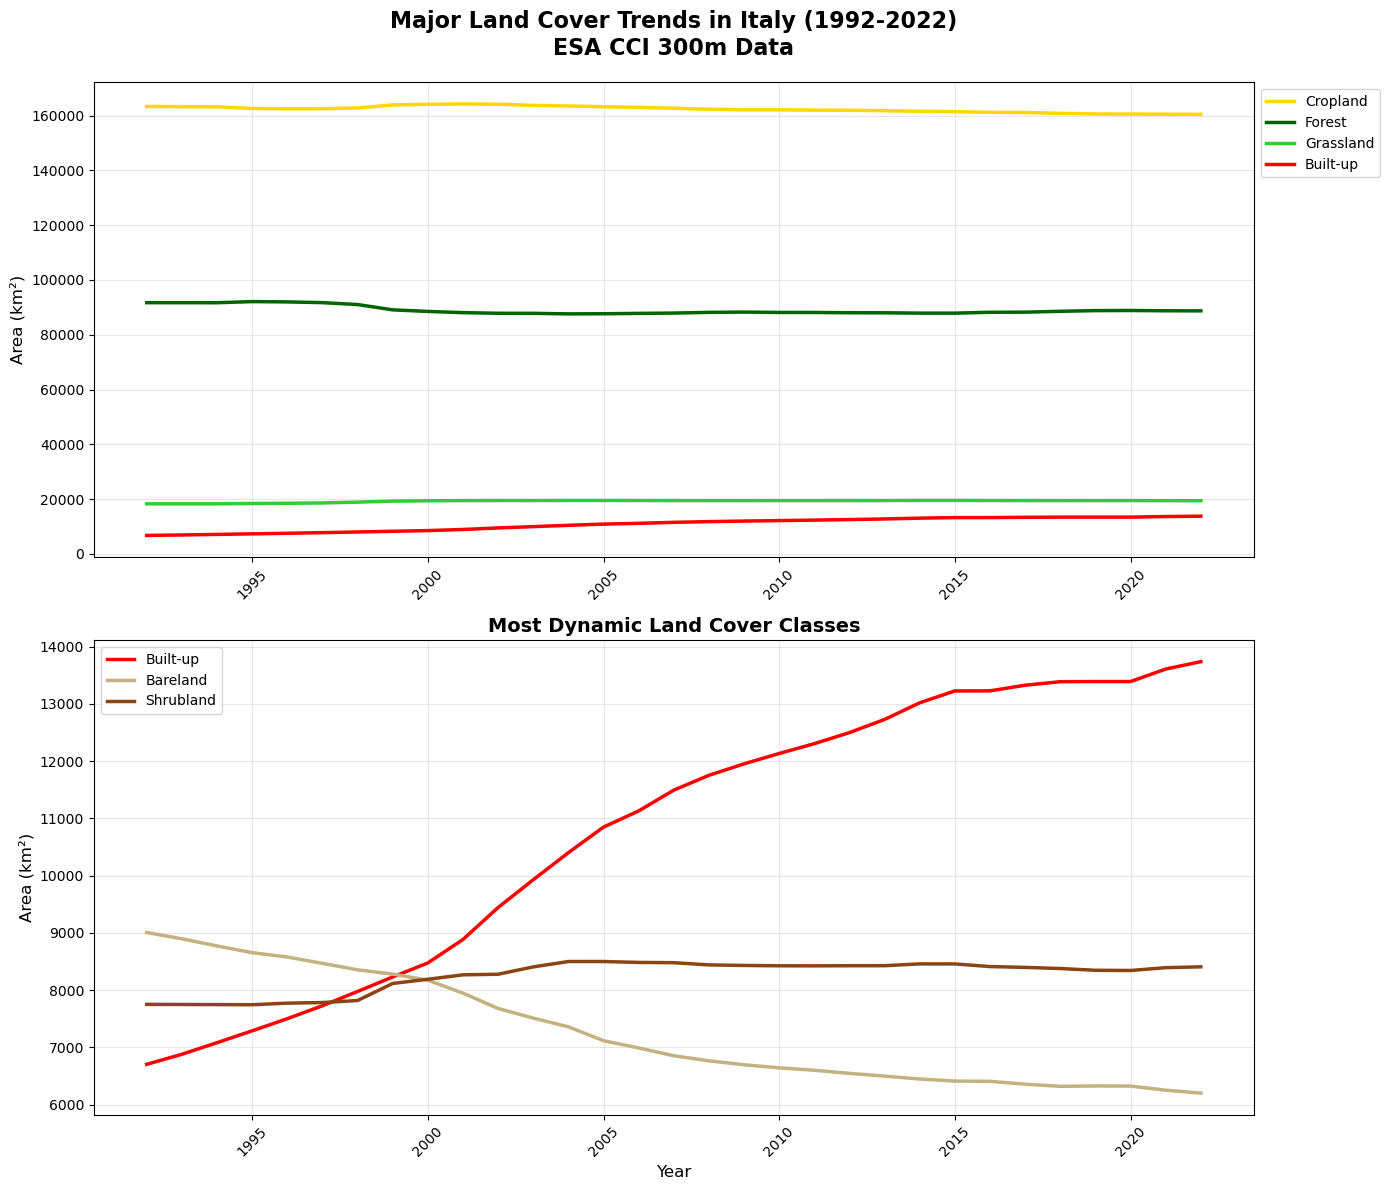

<Figure size 1500x900 with 0 Axes>

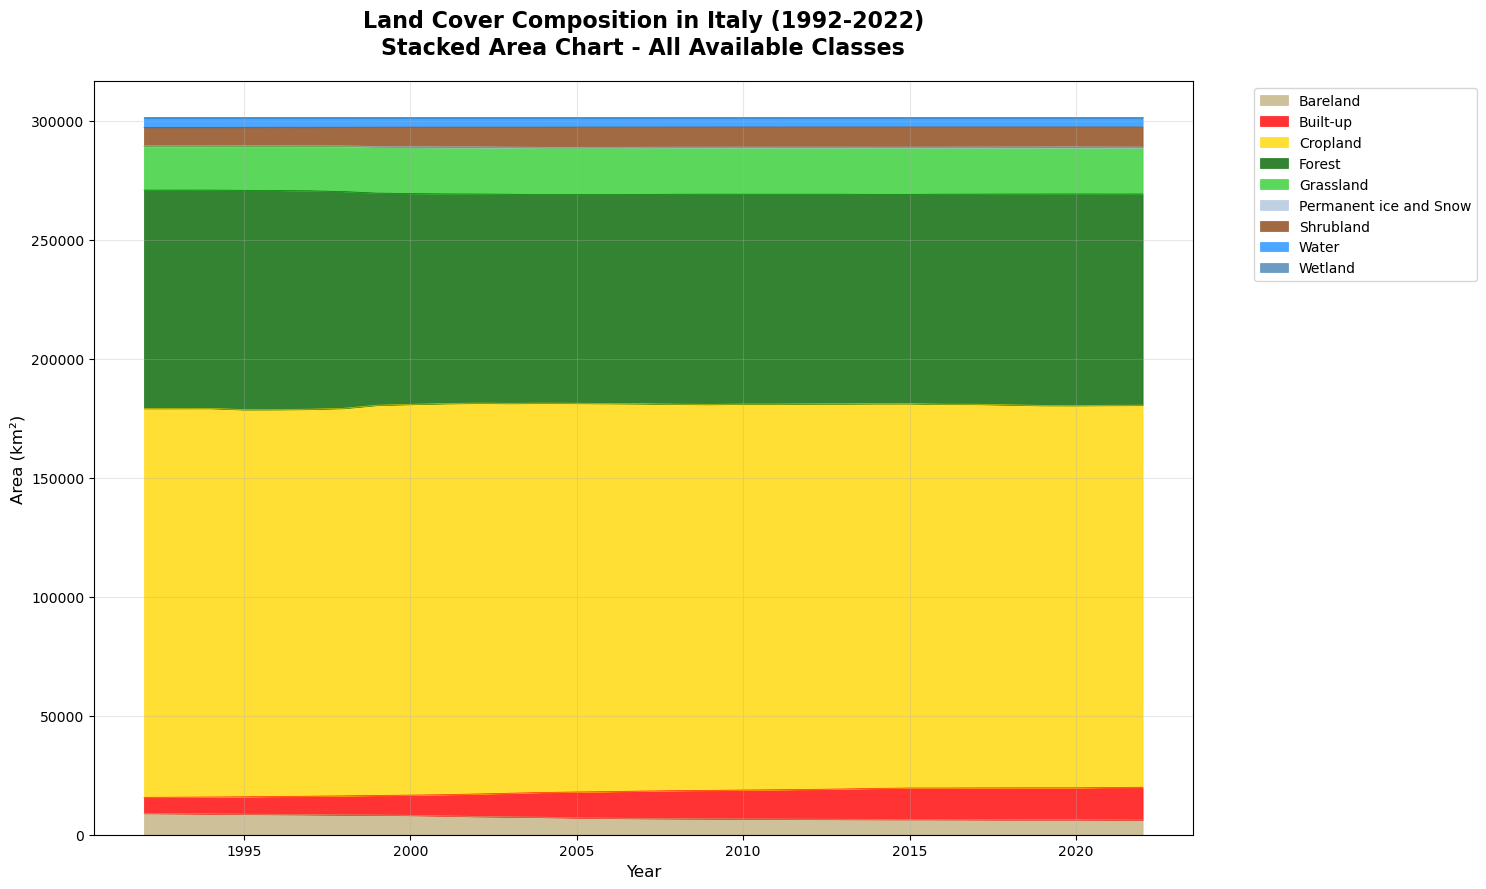

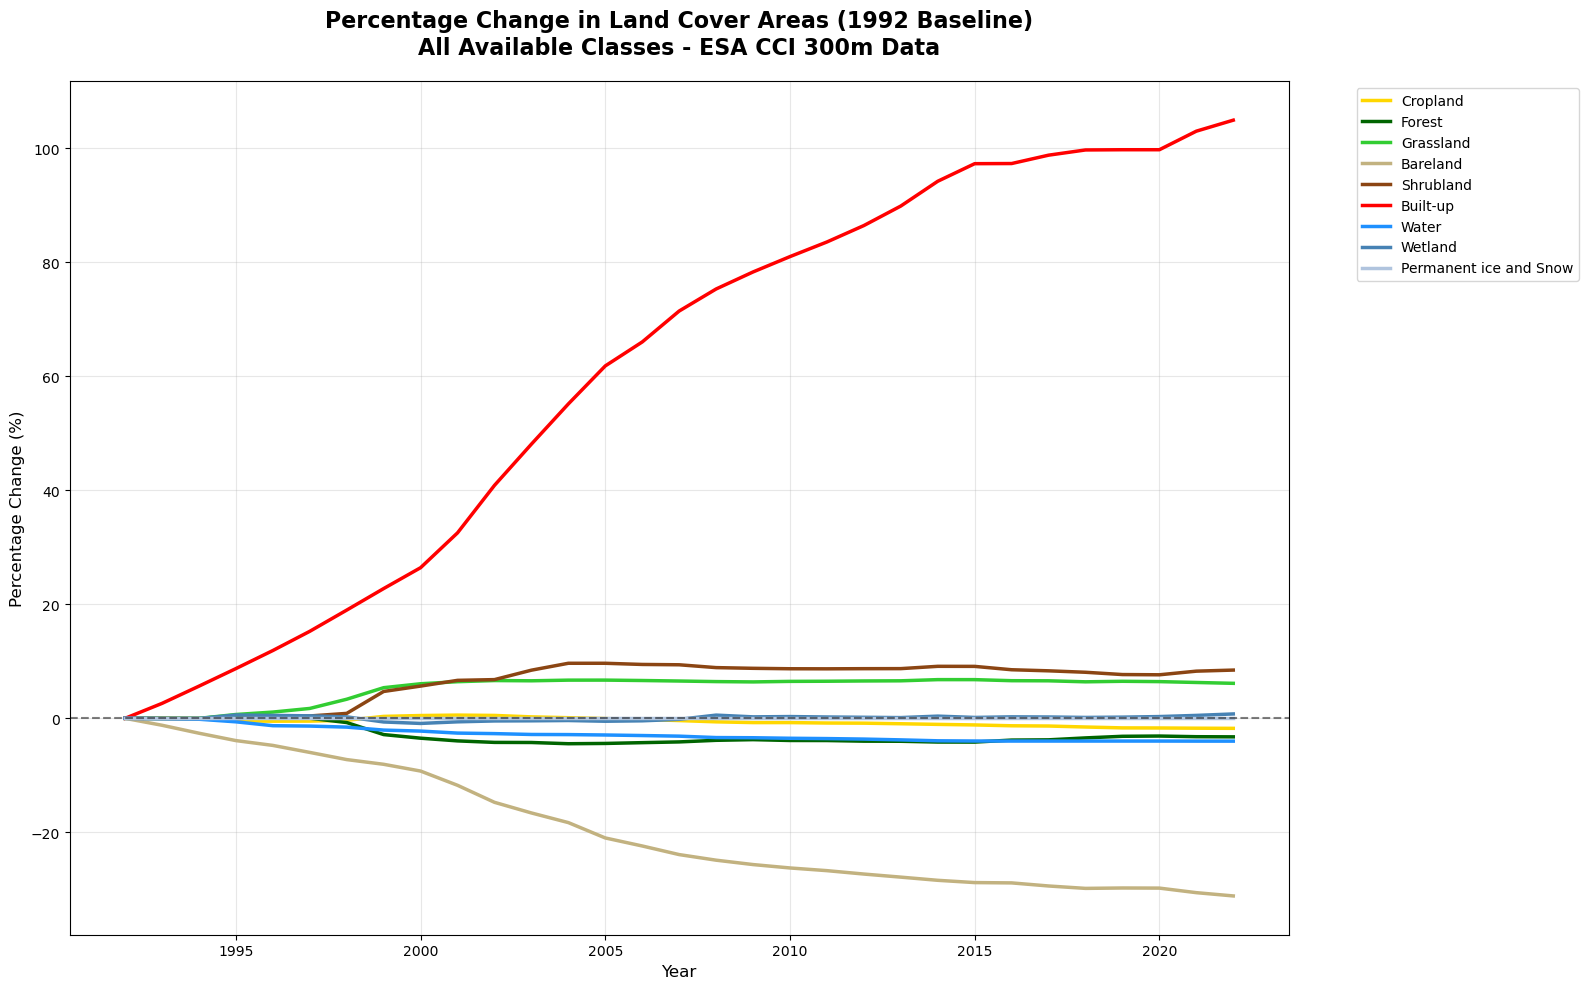

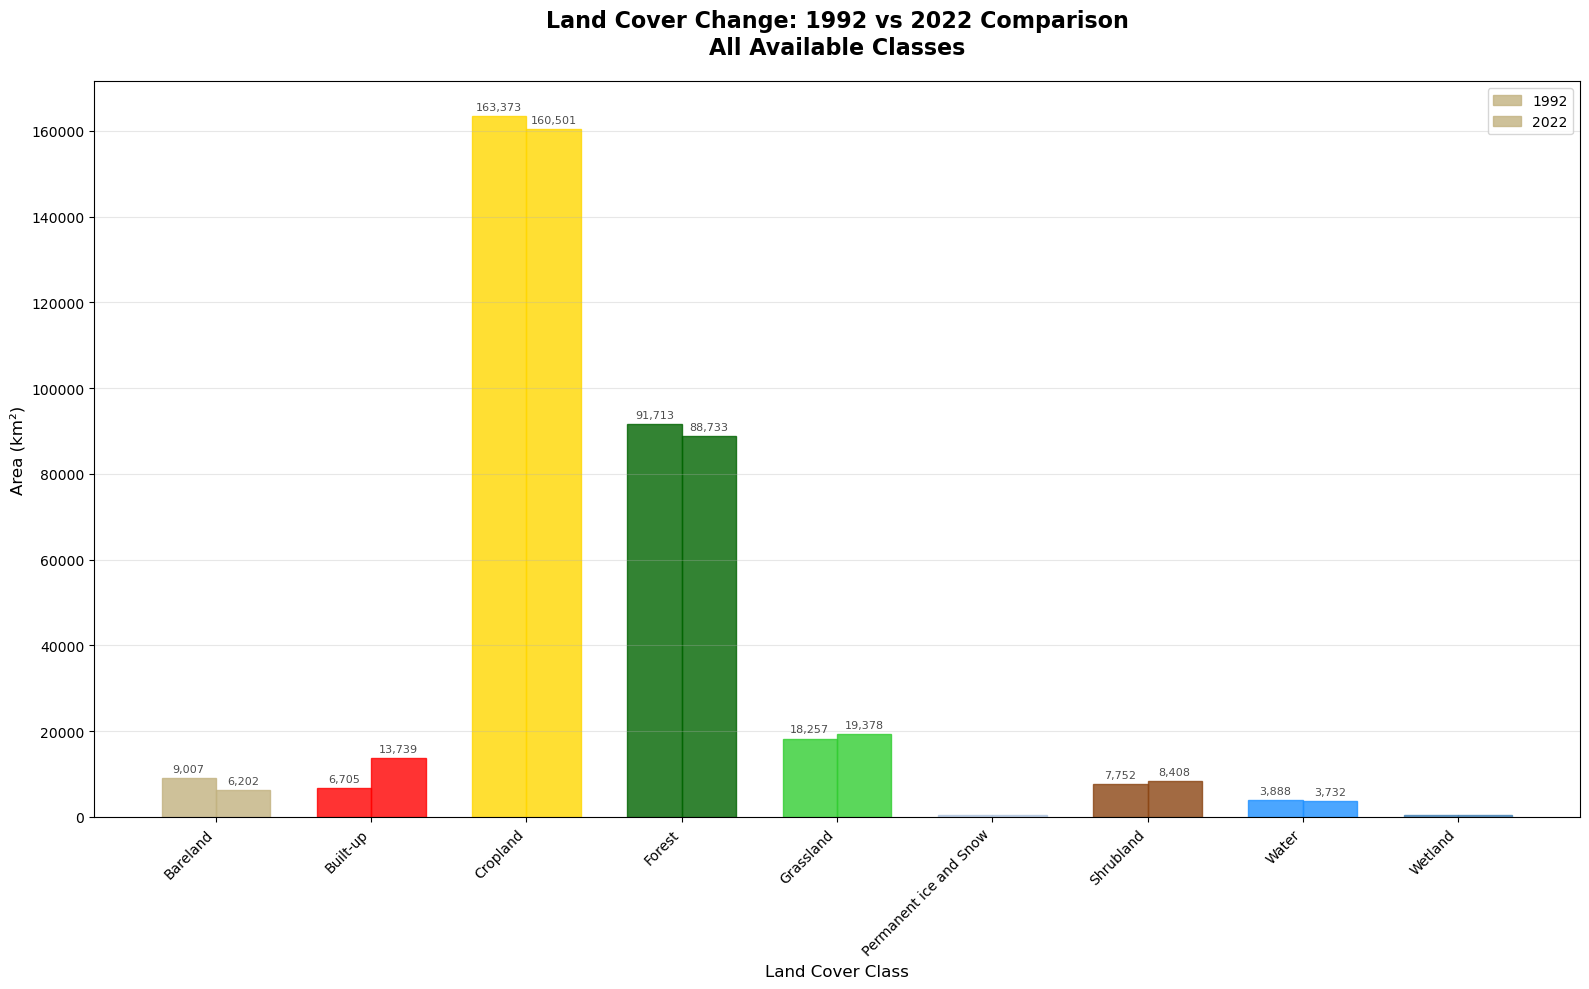

✅ All plots saved in: /Users/ghulamabbaszafari/Downloads/CV/data/CCI_ land cover trend


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ----------------------------
# 1. SETUP AND DATA LOADING
# ----------------------------
# Load the detailed stats CSV
file_path = "/Users/ghulamabbaszafari/Downloads/CV/data/cci_italy_stats_output2/cci_italy_detailed_stats_20250731_185220.csv"
df = pd.read_csv(file_path)

# Convert Year to integer for proper sorting
df['Year'] = df['Year'].str.replace('cci_', '').astype(int)

# Output directory for plots
output_dir = "/Users/ghulamabbaszafari/Downloads/CV/data/CCI_ land cover trend"
os.makedirs(output_dir, exist_ok=True)

# Use your exact color scheme
color_map = {
    'Shrubland': '#8b4513',
    'Grassland': '#32cd32',
    'Cropland': '#ffd700',
    'Wetland': '#4682b4',
    'Lichens and mosses': '#a9cda9',
    'Bareland': '#c2b280',
    'Built-up': '#ff0000',
    'Water': '#1e90ff',
    'Permanent ice and Snow': '#b0c4de',
    'Forest': '#006400',
    'No data': '#ffffff'
}

# ----------------------------
# 2. TIME SERIES TREND PLOTS
# ----------------------------
def create_trend_plots():
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

    # Major classes
    major_classes = ['Cropland', 'Forest', 'Grassland', 'Built-up']
    for class_name in major_classes:
        class_data = df[df['Label'] == class_name].groupby('Year')['Area_km2'].mean()
        ax1.plot(class_data.index, class_data.values,
                 label=class_name, linewidth=2.5, color=color_map[class_name])

    ax1.set_title('Major Land Cover Trends in Italy (1992-2022)\nESA CCI 300m Data',
                  fontsize=16, fontweight='bold', pad=20)
    ax1.set_ylabel('Area (km²)', fontsize=12)
    ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)

    # Changing classes
    changing_classes = ['Built-up', 'Bareland', 'Shrubland']
    for class_name in changing_classes:
        class_data = df[df['Label'] == class_name].groupby('Year')['Area_km2'].mean()
        ax2.plot(class_data.index, class_data.values,
                 label=class_name, linewidth=2.5, color=color_map[class_name])

    ax2.set_title('Most Dynamic Land Cover Classes', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Year', fontsize=12)
    ax2.set_ylabel('Area (km²)', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    save_path = os.path.join(output_dir, "cci_landcover_trends.png")
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()

# ----------------------------
# 3. STACKED AREA CHART
# ----------------------------
def create_stacked_area_chart():
    plt.figure(figsize=(15, 9))
    pivot_df = df.pivot_table(index='Year', columns='Label', values='Area_km2', aggfunc='mean')
    available_classes = [col for col in pivot_df.columns if col in color_map]

    pivot_df[available_classes].plot.area(
        figsize=(15, 9),
        color=[color_map[cls] for cls in available_classes],
        alpha=0.8,
        linewidth=0.5
    )

    plt.title('Land Cover Composition in Italy (1992-2022)\nStacked Area Chart - All Available Classes',
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Area (km²)', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = os.path.join(output_dir, "cci_stacked_area_chart_all_classes.png")
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()

# ----------------------------
# 4. PERCENTAGE CHANGE ANALYSIS
# ----------------------------
def create_percentage_change_plot_all_classes():
    plt.figure(figsize=(16, 10))
    baseline_1992 = df[df['Year'] == 1992].set_index('Label')['Area_km2']
    change_data = {}

    for class_name in df['Label'].unique():
        class_values = df[df['Label'] == class_name].set_index('Year')['Area_km2']
        if class_name in baseline_1992 and baseline_1992[class_name] > 0:
            change_data[class_name] = ((class_values - baseline_1992[class_name]) /
                                       baseline_1992[class_name]) * 100

    change_df = pd.DataFrame(change_data)
    for class_name in change_df.columns:
        plt.plot(change_df.index, change_df[class_name],
                 label=class_name, linewidth=2.5, color=color_map[class_name])

    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.title('Percentage Change in Land Cover Areas (1992 Baseline)\nAll Available Classes - ESA CCI 300m Data',
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Percentage Change (%)', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = os.path.join(output_dir, "cci_percentage_change_all_classes.png")
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()

# ----------------------------
# 5. START/END COMPARISON BAR CHART
# ----------------------------
def create_comparison_barchart_all_classes():
    fig, ax = plt.subplots(figsize=(16, 10))
    data_1992 = df[df['Year'] == 1992].set_index('Label')['Area_km2']
    data_2022 = df[df['Year'] == 2022].set_index('Label')['Area_km2']

    common_classes = sorted(list(set(data_1992.index) & set(data_2022.index)))
    x = np.arange(len(common_classes))
    width = 0.35

    bars1 = ax.bar(x - width/2, [data_1992[cls] for cls in common_classes],
                   width, label='1992', alpha=0.8)
    bars2 = ax.bar(x + width/2, [data_2022[cls] for cls in common_classes],
                   width, label='2022', alpha=0.8)

    for i, cls in enumerate(common_classes):
        bars1[i].set_color(color_map[cls])
        bars2[i].set_color(color_map[cls])

    ax.set_xlabel('Land Cover Class', fontsize=12)
    ax.set_ylabel('Area (km²)', fontsize=12)
    ax.set_title('Land Cover Change: 1992 vs 2022 Comparison\nAll Available Classes',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(common_classes, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # Value labels for bigger bars
    for bar in list(bars1) + list(bars2):
        height = bar.get_height()
        if height > 1000:
            ax.annotate(f'{height:,.0f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8, alpha=0.7)

    plt.tight_layout()
    save_path = os.path.join(output_dir, "cci_1992_vs_2022_all_classes.png")
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()

# ----------------------------
# 6. RUN ALL VISUALIZATIONS
# ----------------------------
if __name__ == "__main__":
    print("Creating CCI land cover visualizations...")
    os.makedirs(output_dir, exist_ok=True)

    plt.style.use('default')
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['font.size'] = 10

    create_trend_plots()
    create_stacked_area_chart()
    create_percentage_change_plot_all_classes()
    create_comparison_barchart_all_classes()

    print(f"✅ All plots saved in: {output_dir}")




Creating stylish land cover visualizations...


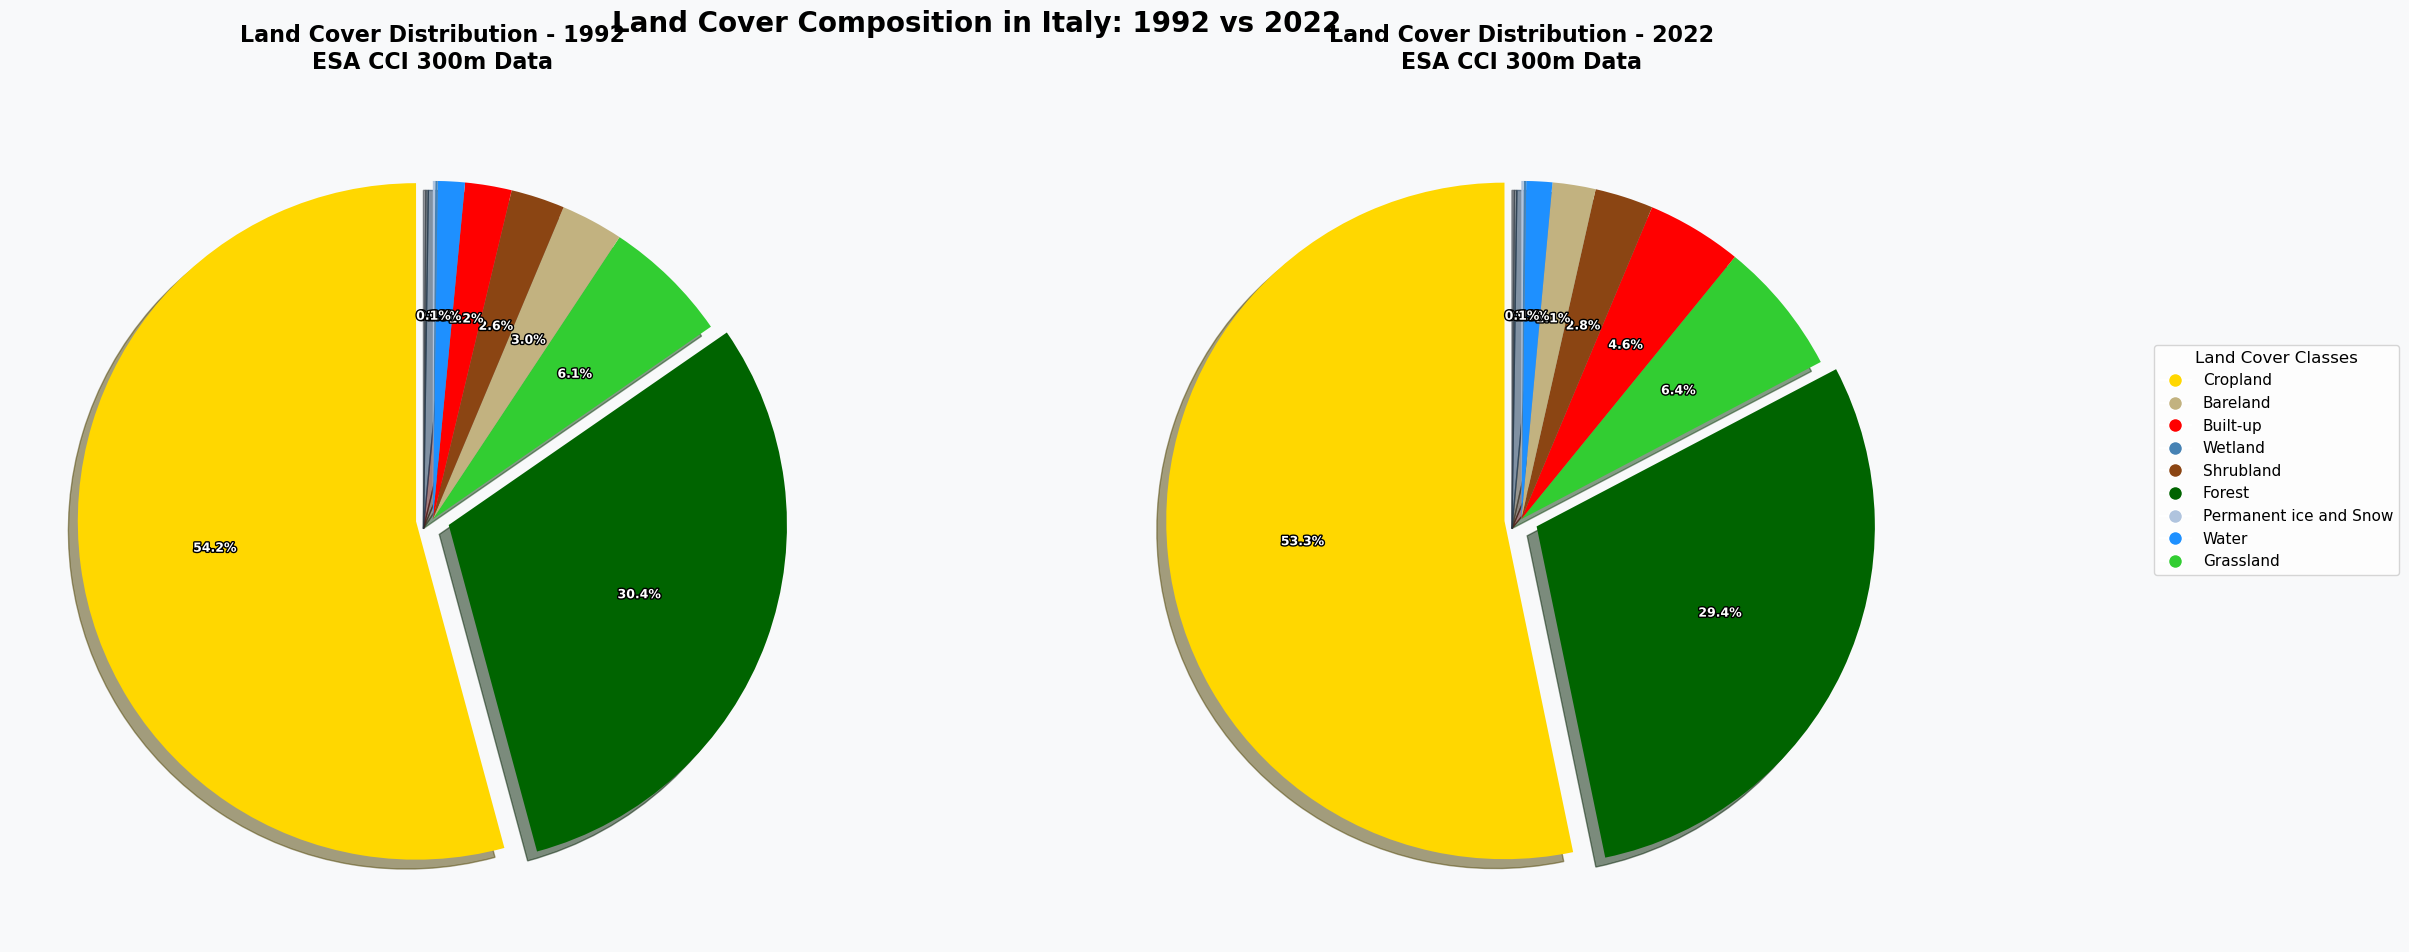

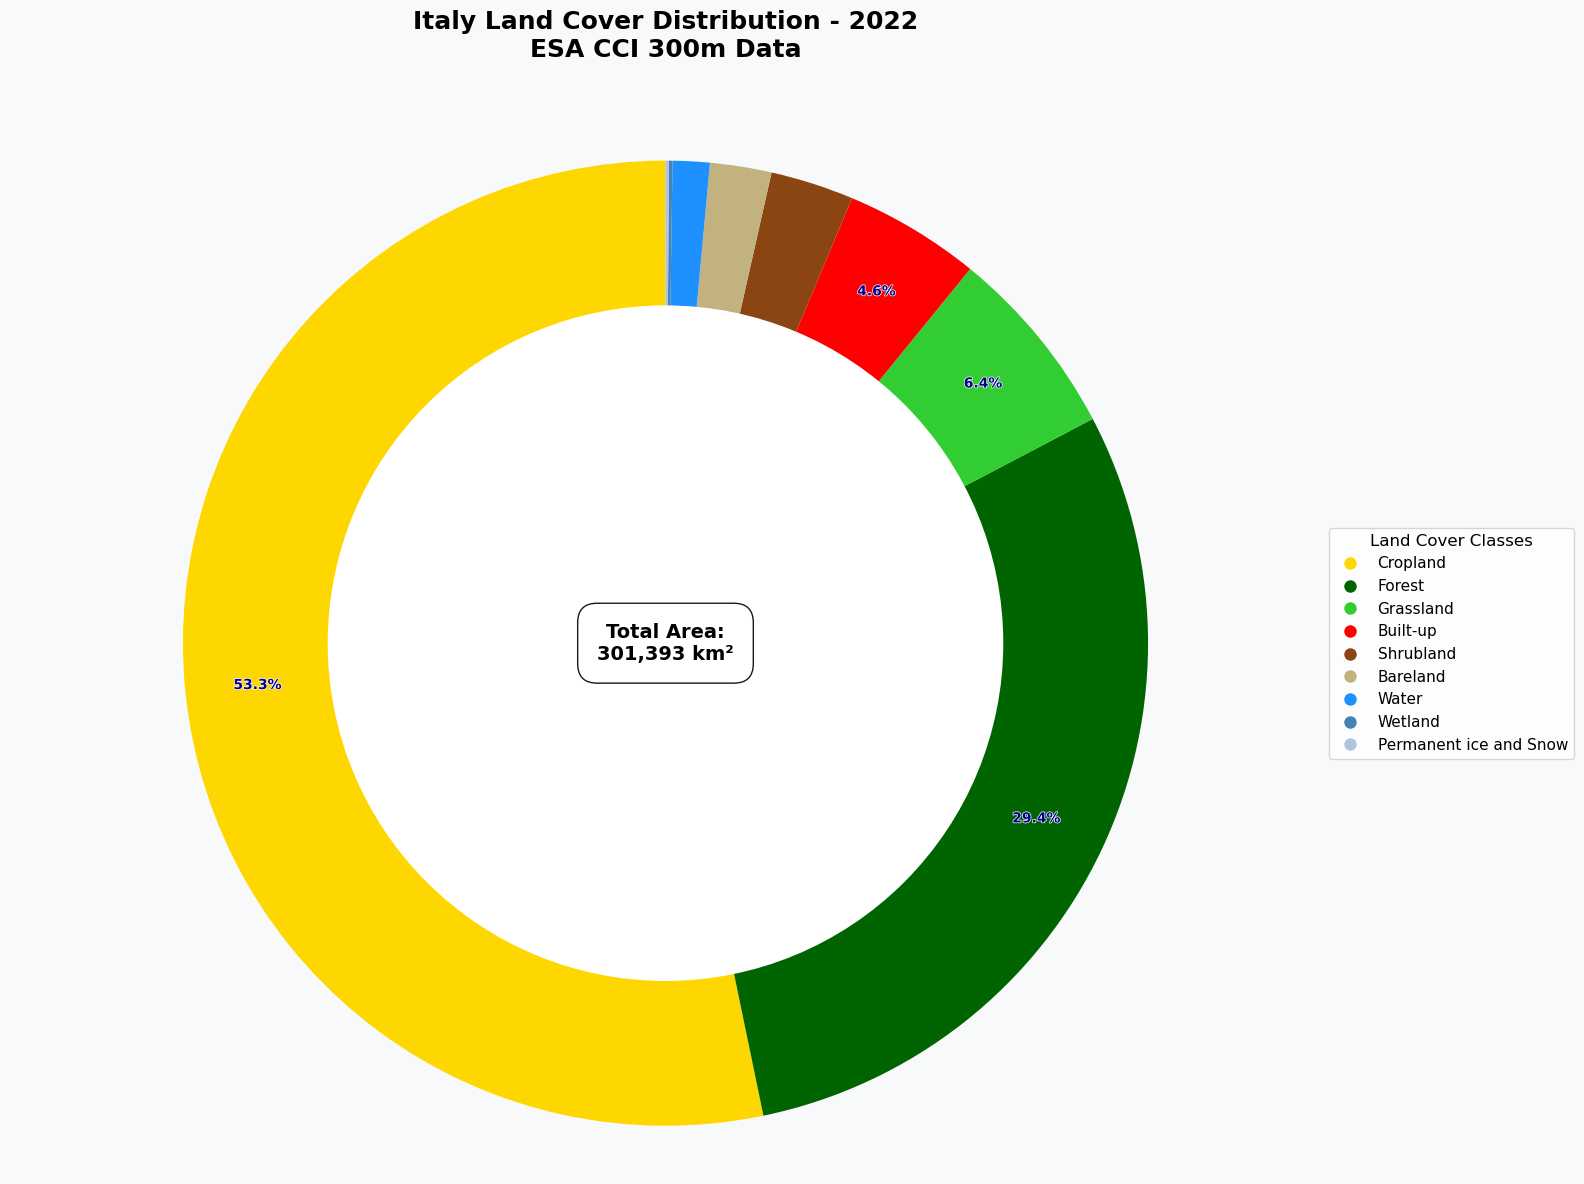

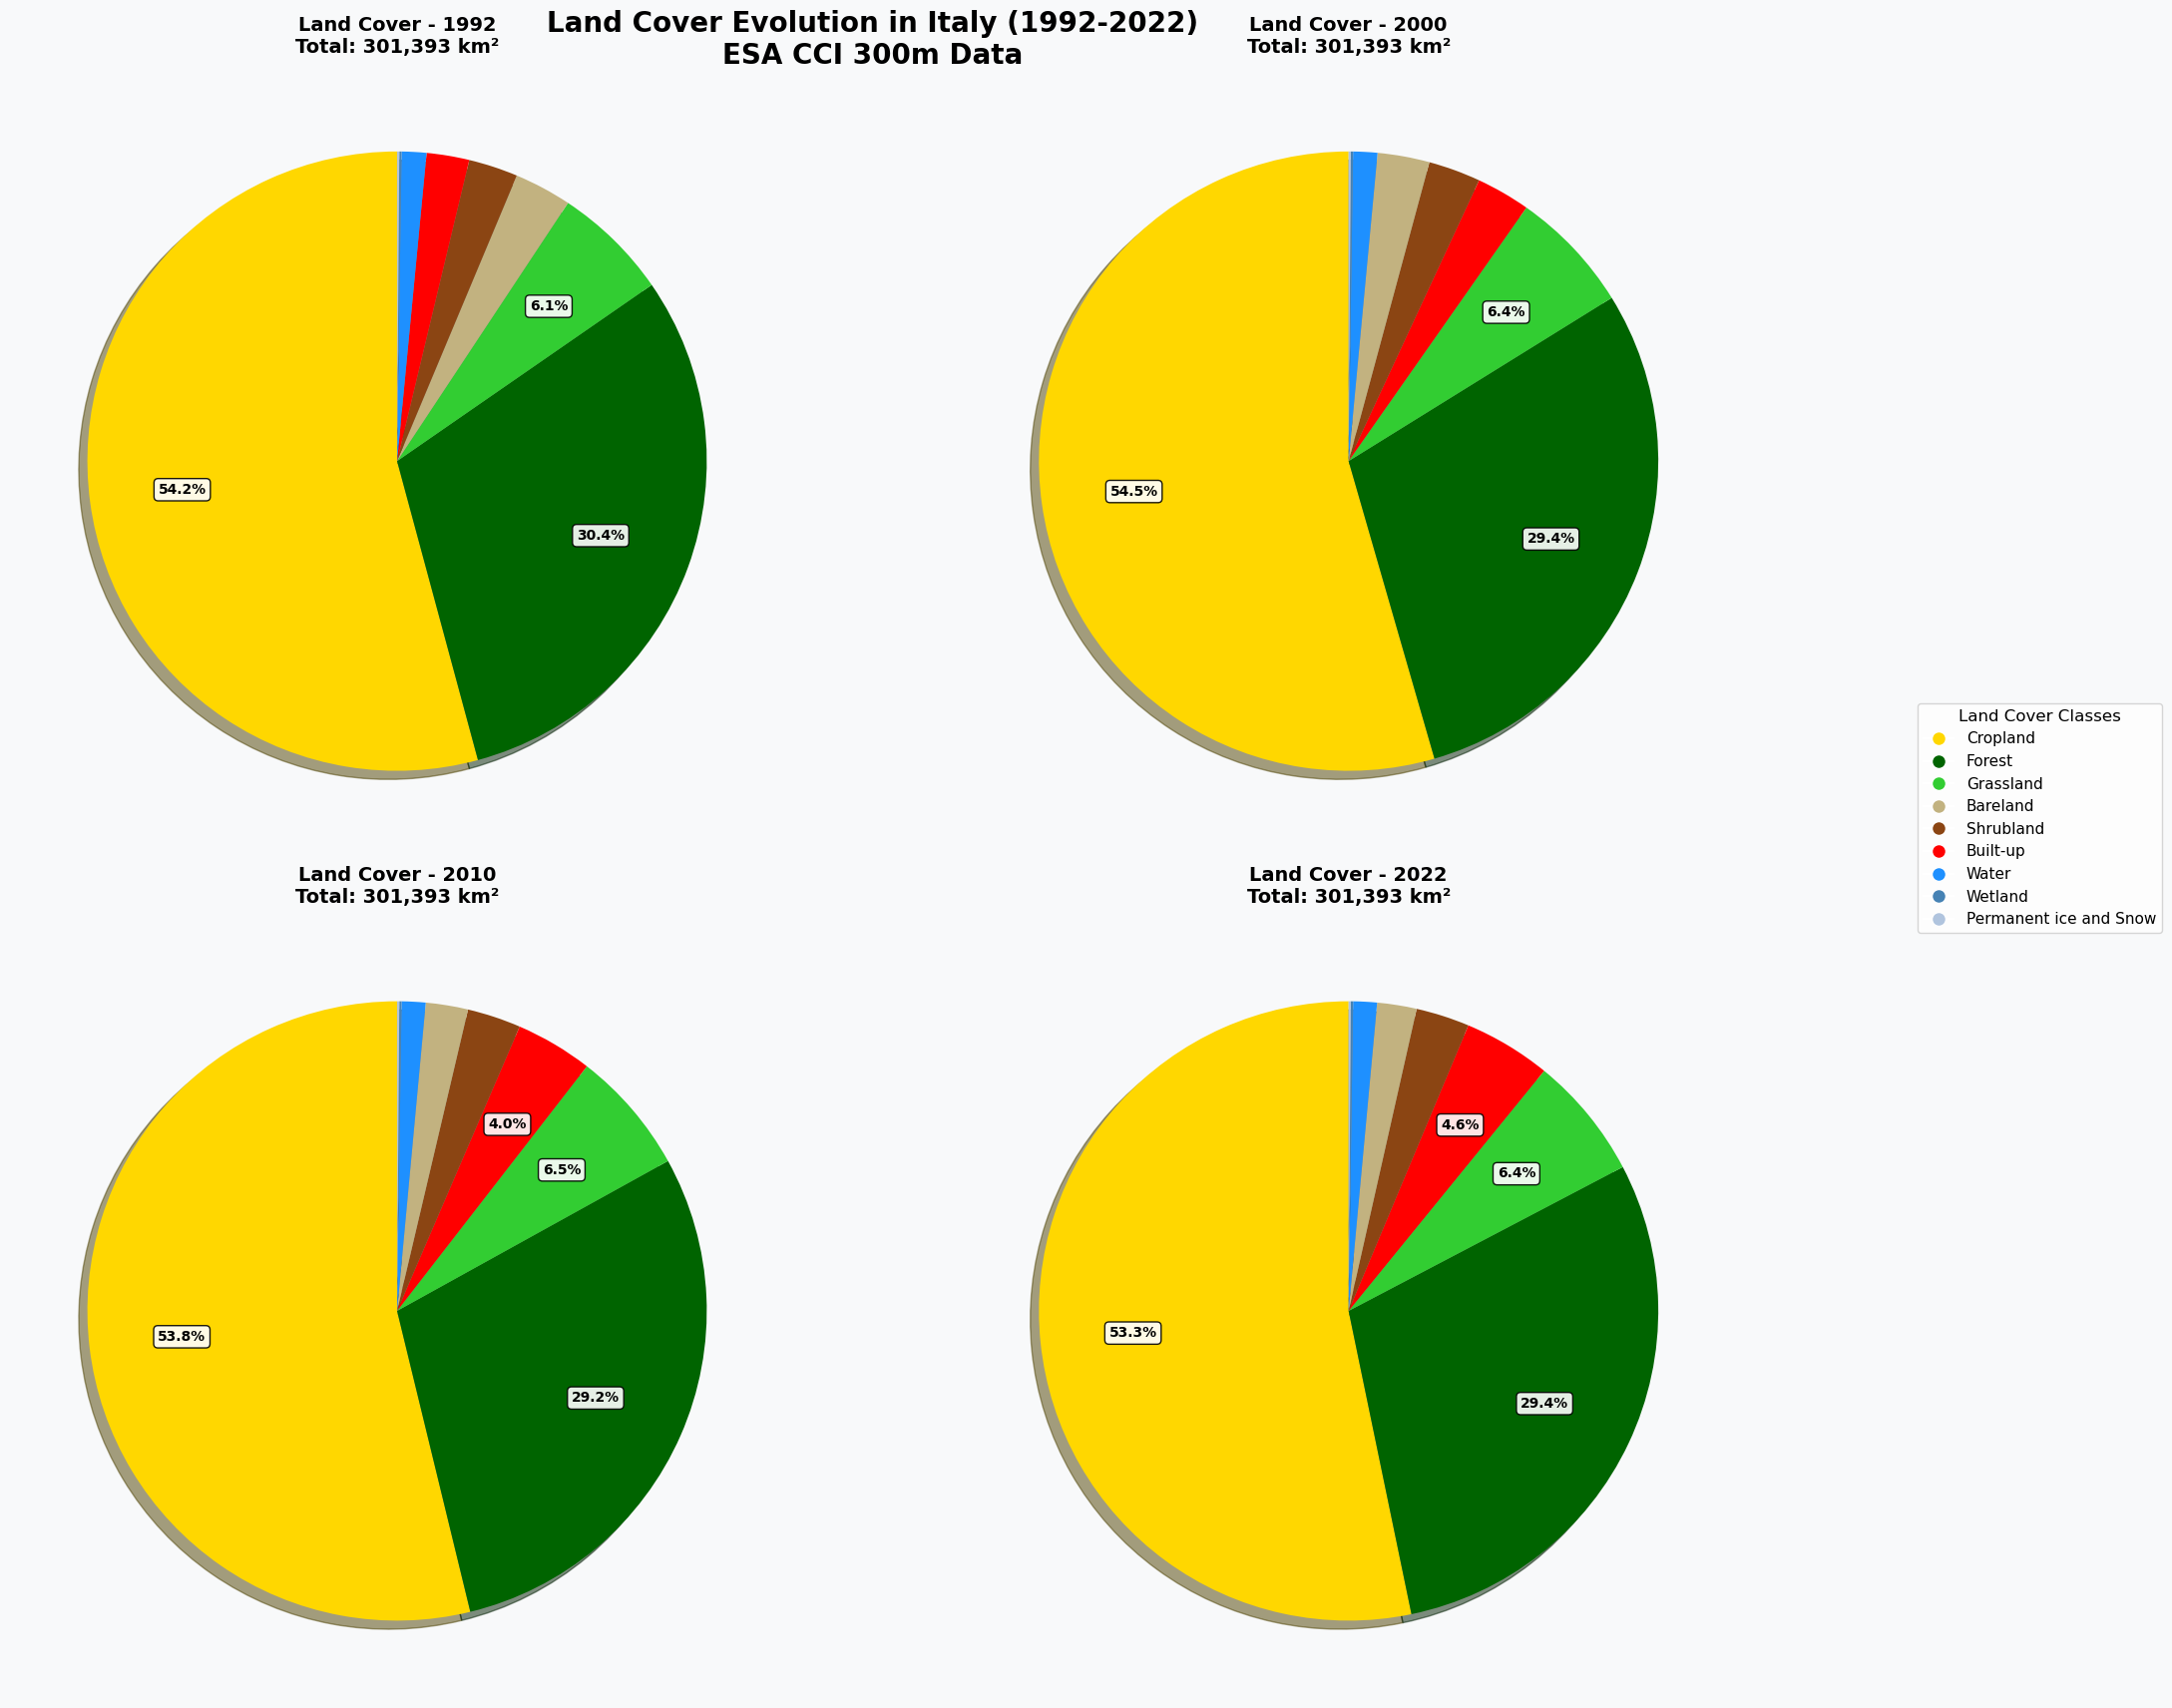

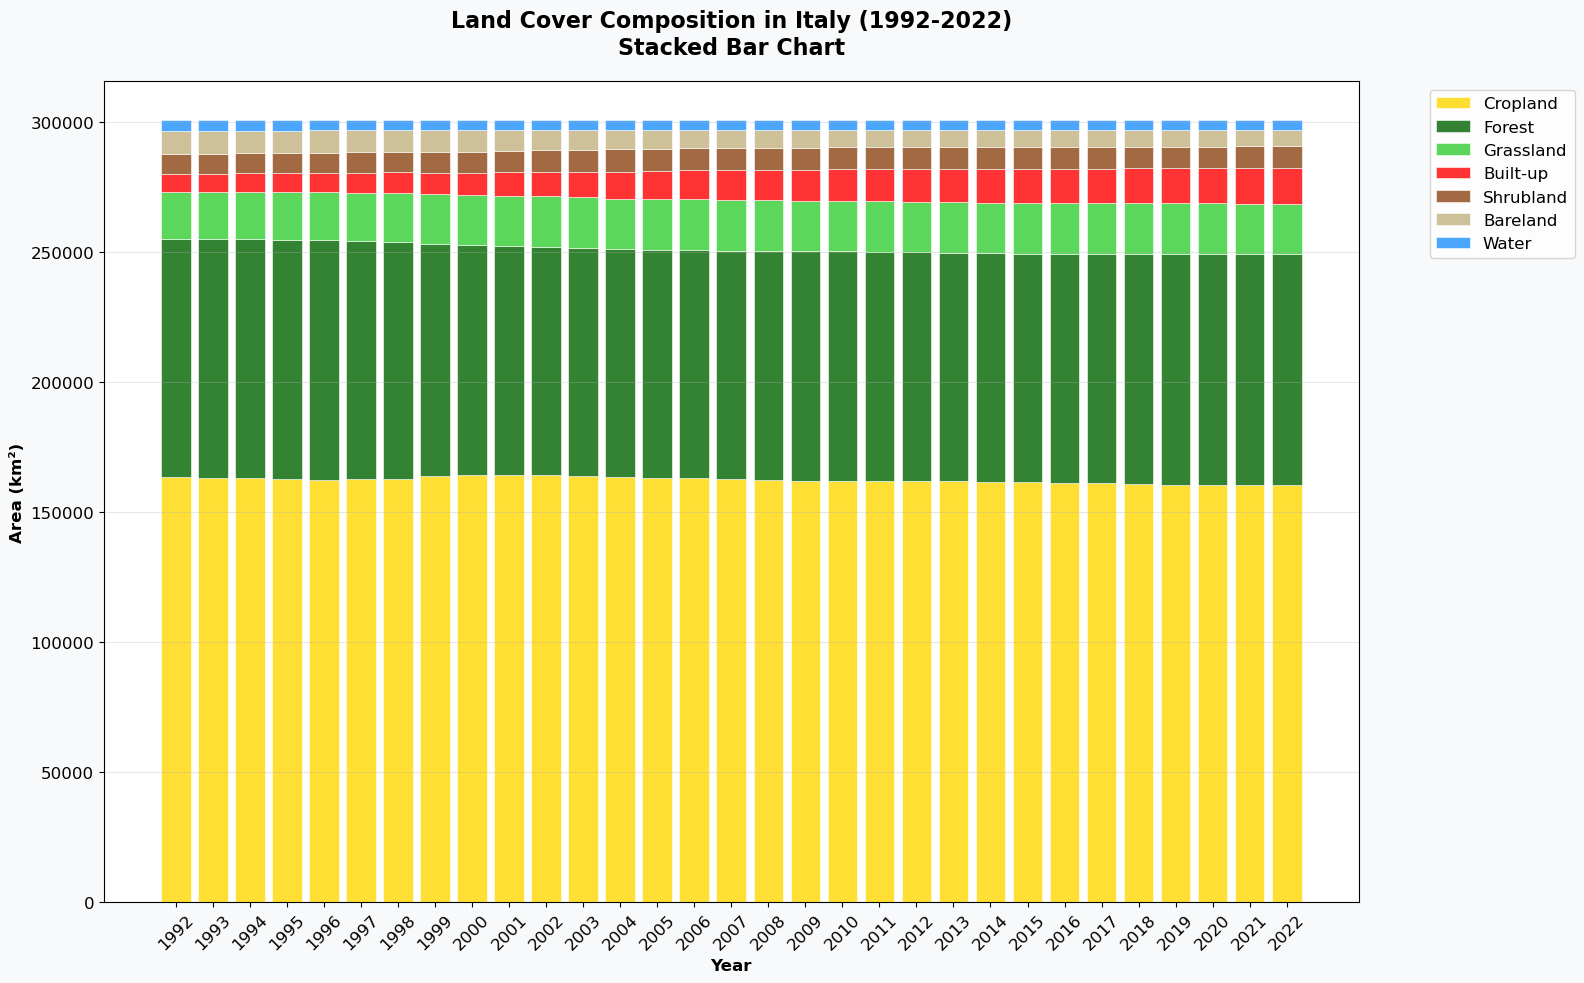

✅ Visualizations completed! PNG files saved in: /Users/ghulamabbaszafari/Downloads/CV/data/CCI_stats_piechart


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import patheffects
import os

# ----------------------------
# 1. SETUP AND DATA LOADING
# ----------------------------
# Load the detailed stats CSV
file_path = "/Users/ghulamabbaszafari/Downloads/CV/data/cci_italy_stats_output2/cci_italy_detailed_stats_20250731_185220.csv"
df = pd.read_csv(file_path)

# Output directory for saving figures
output_dir = "/Users/ghulamabbaszafari/Downloads/CV/data/CCI_stats_piechart"
os.makedirs(output_dir, exist_ok=True)

# Convert Year to integer for proper sorting
df['Year'] = df['Year'].str.replace('cci_', '').astype(int)

# Use your exact color scheme
color_map = {
    'Shrubland': '#8b4513',
    'Grassland': '#32cd32',
    'Cropland': '#ffd700',
    'Wetland': '#4682b4',
    'Lichens and mosses': '#a9cda9',
    'Bareland': '#c2b280',
    'Built-up': '#ff0000',
    'Water': '#1e90ff',
    'Permanent ice and Snow': '#b0c4de',
    'Forest': '#006400',
    'No data': '#ffffff'
}

# ----------------------------
# 2. STYLISH PIE CHARTS FOR START AND END YEARS
# ----------------------------
def create_stylish_pie_charts():
    """Create attractive pie charts for 1992 and 2022"""
    data_1992 = df[df['Year'] == 1992]
    data_2022 = df[df['Year'] == 2022]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['font.size'] = 12
    
    labels_1992 = data_1992['Label'].tolist()
    sizes_1992 = data_1992['Area_km2'].tolist()
    colors_1992 = [color_map[label] for label in labels_1992]
    explode = [0.05 if size > max(sizes_1992)*0.5 else 0 for size in sizes_1992]
    
    wedges_1992, texts_1992, autotexts_1992 = ax1.pie(
        sizes_1992, labels=None, colors=colors_1992,
        autopct='%1.1f%%', startangle=90, explode=explode,
        shadow=True, textprops={'fontsize': 9, 'fontweight': 'bold'}
    )
    for autotext in autotexts_1992:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_path_effects([patheffects.withStroke(linewidth=2, foreground='black')])
    ax1.set_title('Land Cover Distribution - 1992\nESA CCI 300m Data',
                 fontsize=16, fontweight='bold', pad=20)
    
    labels_2022 = data_2022['Label'].tolist()
    sizes_2022 = data_2022['Area_km2'].tolist()
    colors_2022 = [color_map[label] for label in labels_2022]
    wedges_2022, texts_2022, autotexts_2022 = ax2.pie(
        sizes_2022, labels=None, colors=colors_2022,
        autopct='%1.1f%%', startangle=90, explode=explode,
        shadow=True, textprops={'fontsize': 9, 'fontweight': 'bold'}
    )
    for autotext in autotexts_2022:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_path_effects([patheffects.withStroke(linewidth=2, foreground='black')])
    ax2.set_title('Land Cover Distribution - 2022\nESA CCI 300m Data',
                 fontsize=16, fontweight='bold', pad=20)
    
    all_labels = list(set(labels_1992 + labels_2022))
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                                  markerfacecolor=color_map[label],
                                  markersize=10, label=label) for label in all_labels]
    fig.legend(handles=legend_elements,
               loc='center right',
               bbox_to_anchor=(1.15, 0.5),
               fontsize=11,
               title="Land Cover Classes",
               title_fontsize=12)
    plt.suptitle('Land Cover Composition in Italy: 1992 vs 2022',
                 fontsize=20, fontweight='bold', y=0.95)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "italy_landcover_pie_charts.png"),
                dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()

# ----------------------------
# 3. DONUT CHART FOR 2022
# ----------------------------
def create_donut_chart():
    data_2022 = df[df['Year'] == 2022]
    fig, ax = plt.subplots(figsize=(16, 12))
    
    labels = data_2022['Label'].tolist()
    sizes = data_2022['Area_km2'].tolist()
    colors = [color_map[label] for label in labels]
    
    wedges, texts, autotexts = ax.pie(
        sizes, labels=None, colors=colors,
        autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',
        startangle=90, pctdistance=0.85,
        textprops={'fontsize': 10, 'fontweight': 'bold'}
    )
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    ax.add_artist(centre_circle)
    for autotext in autotexts:
        autotext.set_color('darkblue')
        autotext.set_fontweight('bold')
        autotext.set_path_effects([patheffects.withStroke(linewidth=1, foreground='white')])
    ax.axis('equal')
    
    plt.title('Italy Land Cover Distribution - 2022\nESA CCI 300m Data\n',
             fontsize=18, fontweight='bold', pad=20)
    total_area = sum(sizes)
    plt.text(0, 0, f'Total Area:\n{total_area:,.0f} km²',
             ha='center', va='center',
             fontsize=14, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=1'))
    
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                                  markerfacecolor=color_map[label],
                                  markersize=10, label=f"{label}")
                      for label in labels]
    ax.legend(handles=legend_elements,
              loc='center left',
              bbox_to_anchor=(1, 0.5),
              fontsize=11,
              title="Land Cover Classes",
              title_fontsize=12)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "italy_landcover_donut_2022.png"),
                dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()

# ----------------------------
# 4. MULTIPLE YEAR PIES
# ----------------------------
def create_multiple_year_pies():
    selected_years = [1992, 2000, 2010, 2022]
    fig, axes = plt.subplots(2, 2, figsize=(20, 18))
    axes = axes.flatten()
    
    for i, year in enumerate(selected_years):
        year_data = df[df['Year'] == year]
        labels = year_data['Label'].tolist()
        sizes = year_data['Area_km2'].tolist()
        colors = [color_map[label] for label in labels]
        
        wedges, texts, autotexts = axes[i].pie(
            sizes, colors=colors,
            autopct='', startangle=90, shadow=True, labels=None
        )
        total = sum(sizes)
        for j, (wedge, size) in enumerate(zip(wedges, sizes)):
            if size / total > 0.03:
                angle = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
                x = 0.7 * np.cos(np.deg2rad(angle))
                y = 0.7 * np.sin(np.deg2rad(angle))
                percentage = (size / total) * 100
                axes[i].text(x, y, f'{percentage:.1f}%',
                             ha='center', va='center',
                             fontweight='bold', fontsize=10,
                             bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9))
        axes[i].set_title(f'Land Cover - {year}\nTotal: {total:,.0f} km²',
                         fontsize=14, fontweight='bold', pad=15)
        axes[i].set_aspect('equal')
    
    unique_labels = list(df['Label'].unique())
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                                  markerfacecolor=color_map[label],
                                  markersize=10, label=label)
                      for label in unique_labels]
    fig.legend(handles=legend_elements,
              loc="center right",
              bbox_to_anchor=(1.15, 0.5),
              fontsize=11,
              title="Land Cover Classes",
              title_fontsize=12)
    
    plt.suptitle('Land Cover Evolution in Italy (1992-2022)\nESA CCI 300m Data',
                fontsize=20, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "italy_landcover_multiple_years.png"),
                dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()

# ----------------------------
# 5. BAR PLOT
# ----------------------------
def create_landcover_bar_plot():
    pivot_df = df.pivot_table(index='Year', columns='Label', values='Area_km2', aggfunc='sum')
    main_classes = ['Cropland', 'Forest', 'Grassland', 'Built-up', 'Shrubland', 'Bareland', 'Water']
    pivot_df = pivot_df[main_classes]
    
    fig, ax = plt.subplots(figsize=(16, 10))
    years = pivot_df.index
    x = np.arange(len(years))
    bottom = np.zeros(len(years))
    
    for class_name in main_classes:
        values = pivot_df[class_name].values
        ax.bar(x, values, label=class_name, color=color_map[class_name],
               bottom=bottom, alpha=0.8, edgecolor='white', linewidth=0.5)
        bottom += values
    
    ax.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax.set_ylabel('Area (km²)', fontsize=12, fontweight='bold')
    ax.set_title('Land Cover Composition in Italy (1992-2022)\nStacked Bar Chart',
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(years, rotation=45)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "italy_landcover_stacked_bars.png"),
                dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()

# ----------------------------
# 6. RUN ALL VISUALIZATIONS
# ----------------------------
if __name__ == "__main__":
    print("Creating stylish land cover visualizations...")
    plt.style.use('default')
    plt.rcParams['figure.facecolor'] = '#f8f9fa'
    
    create_stylish_pie_charts()
    create_donut_chart()
    create_multiple_year_pies()
    create_landcover_bar_plot()
    
    print(f"✅ Visualizations completed! PNG files saved in: {output_dir}")


